# I - Upgrade Colab to **Colab Pro for FREE** as student
- Enter https://colab.research.google.com/signup to upgrade
- Otherwise, you can only use a old GPU which is 5x slower than Colab Pro can provide you.


# II - Baseline Production for Robust Finetiuining

## 0.Switch Runtime type to GPU (See top right)
- Click change runtime type
- Switch to **A100 GPU** (my example using a worse T4 gpu)

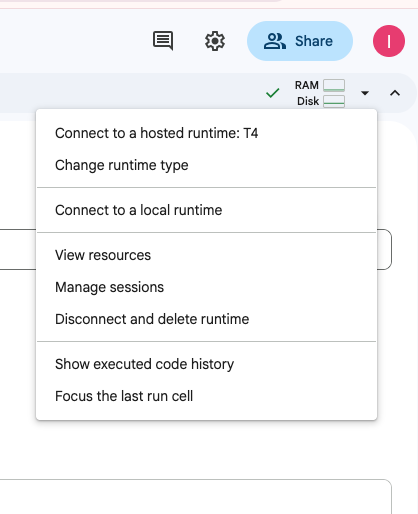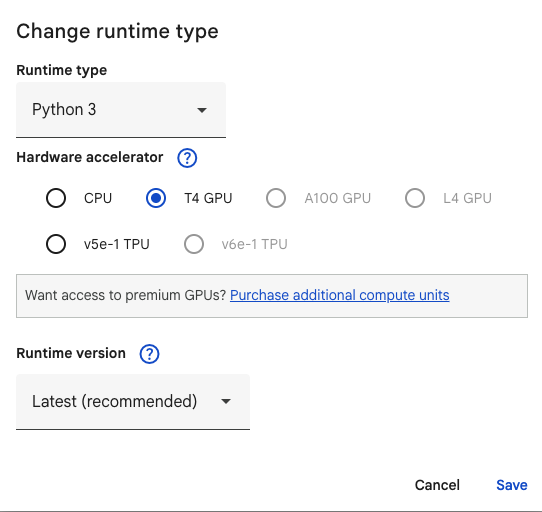

## 1.Github Clone

- **Mount Your Google Drive**
  - Note: `/content/` is a temperary folder which means that everything stored in this folder might be automatically deleted after ~15 hours. So please mount your google drive (Gdrive) as follows and store you imporant files such as code into your Gdrive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/workspace

/content/drive/MyDrive/workspace


- **Git Clone Code (one-time)**
  - This step is a **one-time** setup. Once you clone the code into your Gdrive, you don't have to do it again.



In [ ]:
!git clone https://github.com/changliu816/DPS.git

Cloning into 'DPS'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 119 (delta 31), reused 97 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 2.87 MiB | 10.04 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [ ]:
%cd DPS/
!mkdir checkpoints

/content/drive/MyDrive/workspace/DPS


In [ ]:
!ls
!pwd

clip  datacreation_scripts  install.sh	LICENSE  README.md  src
/content/drive/MyDrive/workspace/DPS


## 2.Dataset Downloading

- Download dataset to local path at `/content/iwildcamv2.tar` (~2 mins)

In [ ]:
!curl -L -o /content/iwildcamv2.zip https://www.kaggle.com/api/v1/datasets/download/smeustefan/iwildcamv2

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 11.1G  100 11.1G    0     0  21.6M      0  0:08:49  0:08:49 --:--:-- 22.6M


In [ ]:
!unzip /content/iwildcamv2.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/iwildcam_v2.0/train/98e2179e-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e21a96-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e220ae-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e226e4-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e229e6-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e22fe0-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e23c10-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e23eea-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e241d8-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e244e4-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /content/iwildcam_v2.0/train/98e247dc-21bc-11ea-a13a-137349068a90.jpg  
  inflating: /

In [ ]:
!pwd


/content/drive/MyDrive/workspace/DPS


In [ ]:
!mkdir -p datasets/data/iwildcam_v2.0

In [ ]:
!ln -s /content/iwildcam_v2.0 ./datasets/data

In [ ]:
!python datacreation_scripts/iwildcam.py

## 3.Setting up Training Environment

- Install dependency


In [ ]:
!pip install open_clip_torch
!pip install wilds braceexpand webdataset h5py
!pip install git+https://github.com/modestyachts/ImageNetV2_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 8.0 MB/s eta 0:00:00
  Cloning https://github.com/modestyachts/ImageNetV2_pytorch to /tmp/pip-req-build-vdvmeow0
  Running command git clone --filter=blob:none --quiet https://github.com/modestyachts/ImageNetV2_pytorch /tmp/pip-req-build-vdvmeow0
  Resolved https://github.com/modestyachts/ImageNetV2_pytorch to commit 14d4456c39fe7f02a665544dd9fc37c1a5f8b635
  Preparing metadata (setup.py) ... done
  Created wheel for imagenetv2_pytorch: filename=imagenetv2_pytorch-0.1-py3-none-any.whl size=2658 sha256=32ceacbd0dc0970dffc60c2f13a5cc22241a1acb30bbe3fed63a54055a22b716
  Stored in directory: /tmp/pip-ephem-wheel-cache-g04w2l

## 4.Launch Training job
- Train models from scratch using Full Finetuning (FT) as algorithm

- Evaluate performance and compare against benchmark results reported by the authors w.r.t **OOD acc** and **Macro-F1** score Table 1 Row 3 (FT) in https://arxiv.org/pdf/2212.00638.

In [ ]:
!export PYTHONPATH="$PYTHONPATH:$PWD"

In [ ]:

!PYTHONPATH=$PYTHONPATH:. python src/main.py --train-dataset=IWildCamIDVal \
  --epochs=2 --lr=1e-5 --wd=0.2 --batch-size=32 \
  --model=ViT-B/16 --eval-datasets=IWildCamIDVal,IWildCamID,IWildCamOOD \
  --template=iwildcam_template  --save=./checkpoints/ \
  --data-location=./datasets/data/ --ft_data="./datasets/csv/iwildcam_v2.0/train.csv" \
  --csv-img-key filepath --csv-caption-key title \
  --exp_name=iwildcam/CE_loss \
  --algorithm=ce

ViT-B/16
Training dataset IWildCamIDVal
Num batches is 4057
Training Epochs:   0% 0/2 [00:00<?, ?it/s]Epoch :  0

0it [00:00, ?it/s]Train Epoch: 0 [0% 0/4057]	ID FLYP Loss: 5.3917

1it [00:06,  6.20s/it]
2it [00:08,  3.76s/it]
3it [00:10,  3.00s/it]
4it [00:12,  2.63s/it]
5it [00:14,  2.44s/it]
6it [00:16,  2.31s/it]
7it [00:18,  2.24s/it]
8it [00:20,  2.19s/it]
9it [00:22,  2.15s/it]
10it [00:24,  2.13s/it]
11it [00:27,  2.12s/it]
12it [00:29,  2.11s/it]
13it [00:31,  2.12s/it]
14it [00:33,  2.11s/it]
15it [00:35,  2.11s/it]
16it [00:37,  2.11s/it]
17it [00:39,  2.12s/it]
18it [00:41,  2.12s/it]
19it [00:43,  2.12s/it]
20it [00:46,  2.13s/it]
21it [00:48,  2.13s/it]
22it [00:50,  2.14s/it]
23it [00:52,  2.14s/it]
24it [00:54,  2.14s/it]
25it [00:56,  2.15s/it]
26it [00:58,  2.15s/it]
27it [01:01,  2.16s/it]
28it [01:03,  2.16s/it]
29it [01:05,  2.17s/it]
30it [01:07,  2.17s/it]
31it [01:09,  2.19s/it]
32it [01:12,  2.22s/it]
33it [01:14,  2.25s/it]
34it [01:16,  2.23s/it]
35it [01:18,

- (Optional) Switch to FLYP algorithms

In [ ]:
!python src/main.py --train-dataset=IWildCamIDVal \
  --epochs=20 --lr=1e-5 --wd=0.2 --batch-size=256 \
  --model=ViT-B/16 --eval-datasets=IWildCamIDVal,IWildCamID,IWildCamOOD \
  --template=iwildcam_template  --save=./checkpoints/ \
  --data-location=./datasets/data/ --ft_data="./datasets/csv/iwildcam_v2.0/train.csv" \
  --csv-img-key filepath --csv-caption-key title \
  --exp_name=iwildcam/flyp_loss

In [ ]:
!ls

checkpoints  datacreation_scripts  datasets    LICENSE	  src
clip	     DATA.md		   install.sh  README.md  venv
